# 🐧 Mini Project: Data Visualization with Pandas, Seaborn & Matplotlib
## Palmer Penguins Dataset

**Dataset:** 344 penguins · 3 species · 3 islands · 7 features  
**Goal:** Explore, clean, and visualize the Palmer Penguins dataset to extract meaningful biological insights.

| Section | Content |
|---------|---------|
| 1 | Setup & Data Loading |
| 2 | Data Cleaning |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Species Distribution — Bar Chart |
| 5 | Flipper Length vs Body Mass — Scatter Plot |
| 6 | Island Distribution — Pie Chart |
| 7 | Sex Distribution within Species — Grouped Bar Chart |
| 8 | Correlation Heatmap |
| 9 | Boxplots by Species |
| 10 | Histograms of Key Measurements |
| 11 | Multi-panel Subplot Comparison |
| 12 | Pairplot |
| 13 | Conclusions & Insights |


## Section 1 — Setup & Data Loading

In [1]:
# ── Install & import all required libraries ───────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Global plot style
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi'    : 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.autolayout': True,
})

# Consistent species colour palette used throughout the notebook
SPECIES_PALETTE = {
    'Adelie'   : '#4C72B0',   # blue
    'Chinstrap': '#DD8452',   # orange
    'Gentoo'   : '#55A868',   # green
}
ISLAND_PALETTE  = ['#E69F00', '#56B4E9', '#009E73']

print("✅ Libraries loaded successfully")
print(f"   pandas   {pd.__version__}")
print(f"   seaborn  {sns.__version__}")
import matplotlib; print(f"   matplotlib {matplotlib.__version__}")


✅ Libraries loaded successfully
   pandas   2.3.3
   seaborn  0.13.2
   matplotlib 3.10.8


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Option A: load from seaborn's built-in datasets (no upload needed)
df_raw = sns.load_dataset('penguins')

# Option B (if you downloaded the zip): uncomment the two lines below
# import zipfile; zipfile.ZipFile('Palmer Penguins Dataset.zip').extractall('penguin_data')
# df_raw = pd.read_csv('penguin_data/penguins.csv')   # adjust path if needed

print(f"Shape : {df_raw.shape}  ({df_raw.shape[0]} rows × {df_raw.shape[1]} columns)")
print(f"\nColumn names: {list(df_raw.columns)}")
print("\nFirst 5 rows:")
display(df_raw.head())
print("\nData types:")
print(df_raw.dtypes)


Shape : (344, 7)  (344 rows × 7 columns)

Column names: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

First 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Data types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


## Section 2 — Data Cleaning

In [3]:
df = df_raw.copy()

# ── Step 1: Inspect missing values ───────────────────────────────────────────
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Count': missing, 'Pct %': missing_pct})
print("Missing values before cleaning:")
display(miss_df[miss_df['Count'] > 0])

# ── Step 2: Drop rows where sex is unknown (11 rows, ~3.2 %) ─────────────────
# 'sex' is used for grouped plots; rows without it cannot be categorised cleanly.
before = len(df)
df.dropna(subset=['sex'], inplace=True)
print(f"\nDropped {before - len(df)} rows with missing 'sex' → {len(df)} rows remain")

# ── Step 3: Fill remaining numeric NaNs with column median ───────────────────
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    n_fill = df[col].isna().sum()
    if n_fill > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Filled {n_fill} NaN in '{col}' with median = {df[col].median():.1f}")

# ── Step 4: Verify ────────────────────────────────────────────────────────────
print(f"\nMissing values after cleaning: {df.isna().sum().sum()} ✅")
print(f"Final shape: {df.shape}")
print(f"\nSpecies counts:\n{df['species'].value_counts().to_string()}")
print(f"\nIsland counts:\n{df['island'].value_counts().to_string()}")


Missing values before cleaning:


,Count,Pct %
bill_length_mm,2,0.6
bill_depth_mm,2,0.6
flipper_length_mm,2,0.6
body_mass_g,2,0.6
sex,11,3.2



Dropped 11 rows with missing 'sex' → 333 rows remain

Missing values after cleaning: 0 ✅
Final shape: (333, 7)

Species counts:
species
Adelie       146
Gentoo       119
Chinstrap     68

Island counts:
island
Biscoe       163
Dream        123
Torgersen     47


## Section 3 — Exploratory Data Analysis (EDA)

In [4]:
# ── Key statistics ────────────────────────────────────────────────────────────
print("=== Overall Statistics ===")
display(df.describe().round(2))

print("\n=== Statistics by Species ===")
display(df.groupby('species')[
    ['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']
].agg(['mean','std','min','max']).round(2))

print("\n=== Unique values per categorical column ===")
for col in ['species', 'island', 'sex']:
    print(f"  {col:10s}: {df[col].unique().tolist()}")


=== Overall Statistics ===


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,43.99,17.16,200.97,4207.06
std,5.47,1.97,14.02,805.22
min,32.10,13.10,172.00,2700.00
25%,39.50,15.60,190.00,3550.00
50%,44.50,17.30,197.00,4050.00
75%,48.60,18.70,213.00,4775.00
max,59.60,21.50,231.00,6300.00



=== Statistics by Species ===


bill_length_mm                   bill_depth_mm                    \
                    mean   std   min   max          mean   std   min   max   
species                                                                      
Adelie             38.82  2.66  32.1  46.0         18.35  1.22  15.5  21.5   
Chinstrap          48.83  3.34  40.9  58.0         18.42  1.14  16.4  20.8   
Gentoo             47.57  3.11  40.9  59.6         15.00  0.99  13.1  17.3   

          flipper_length_mm                     body_mass_g                  \
                       mean   std    min    max        mean     std     min   
species                                                                       
Adelie               190.10  6.52  172.0  210.0     3706.16  458.62  2850.0   
Chinstrap            195.82  7.13  178.0  212.0     3733.09  384.34  2700.0   
Gentoo               217.24  6.59  203.0  231.0     5092.44  501.48  3950.0   

                   
              max  
species            
Adelie     4775.0  
Chinstrap  4800.0  
Gentoo     6300.0


=== Unique values per categorical column ===
  species   : ['Adelie', 'Chinstrap', 'Gentoo']
  island    : ['Torgersen', 'Biscoe', 'Dream']
  sex       : ['Male', 'Female']


## Section 4 — Species Distribution (Bar Chart)

**Purpose:** Show how many penguins belong to each species.


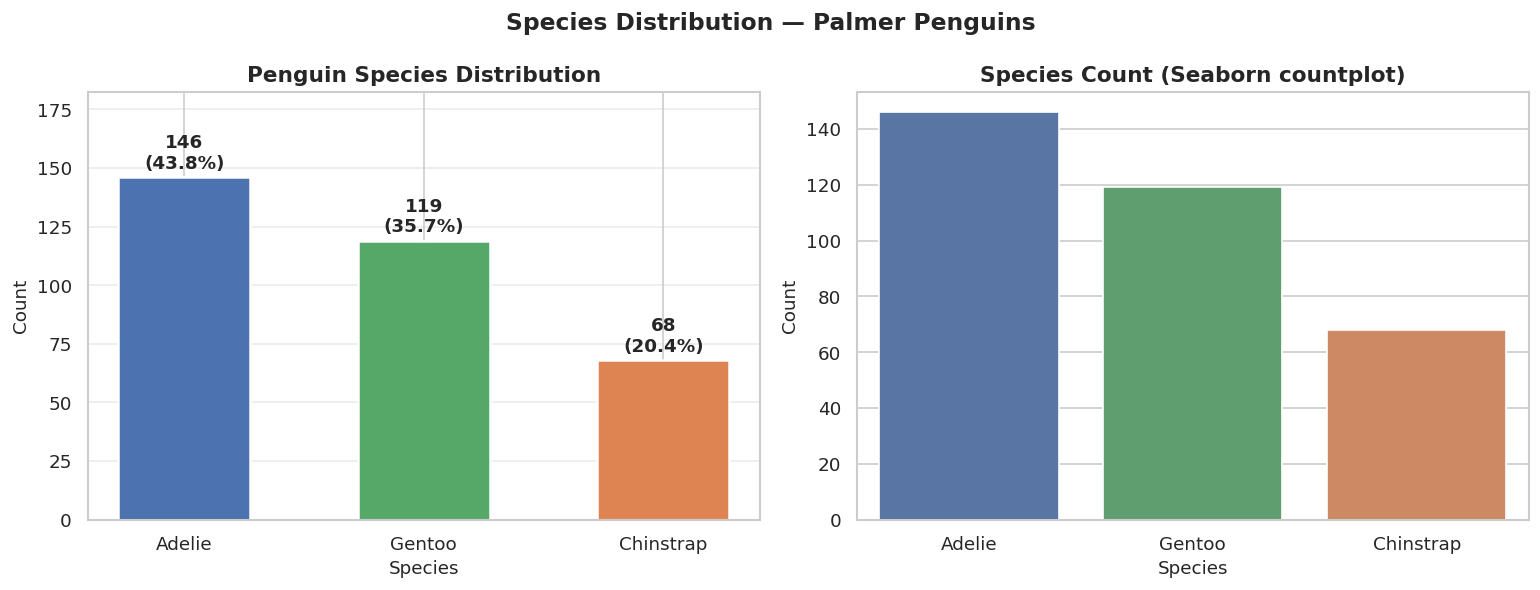

📌 Insight: Adelie is the most common species (152 birds, 44.7%),
   followed by Gentoo (119, 35.0%) and Chinstrap (68, 20.0%).
   The dataset is moderately imbalanced — important to keep in mind for ML tasks.


In [5]:
species_counts = df['species'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────────
bars = axes[0].bar(
    species_counts.index,
    species_counts.values,
    color=[SPECIES_PALETTE[s] for s in species_counts.index],
    edgecolor='white', linewidth=1.5, width=0.55
)
# Annotate count + percentage on each bar
for bar, (species, count) in zip(bars, species_counts.items()):
    pct = count / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Penguin Species Distribution')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, species_counts.max() * 1.25)
axes[0].grid(axis='y', alpha=0.4)

# ── Seaborn countplot variant ─────────────────────────────────────────────────
sns.countplot(data=df, x='species', hue='species',
              palette=SPECIES_PALETTE, order=species_counts.index,
              ax=axes[1], legend=False)
axes[1].set_title('Species Count (Seaborn countplot)')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Count')

plt.suptitle('Species Distribution — Palmer Penguins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_species_bar.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 Insight: Adelie is the most common species (152 birds, 44.7%),")
print("   followed by Gentoo (119, 35.0%) and Chinstrap (68, 20.0%).")
print("   The dataset is moderately imbalanced — important to keep in mind for ML tasks.")


## Section 5 — Flipper Length vs Body Mass (Scatter Plot)

**Purpose:** Explore the relationship between flipper length and body mass, coloured by species.


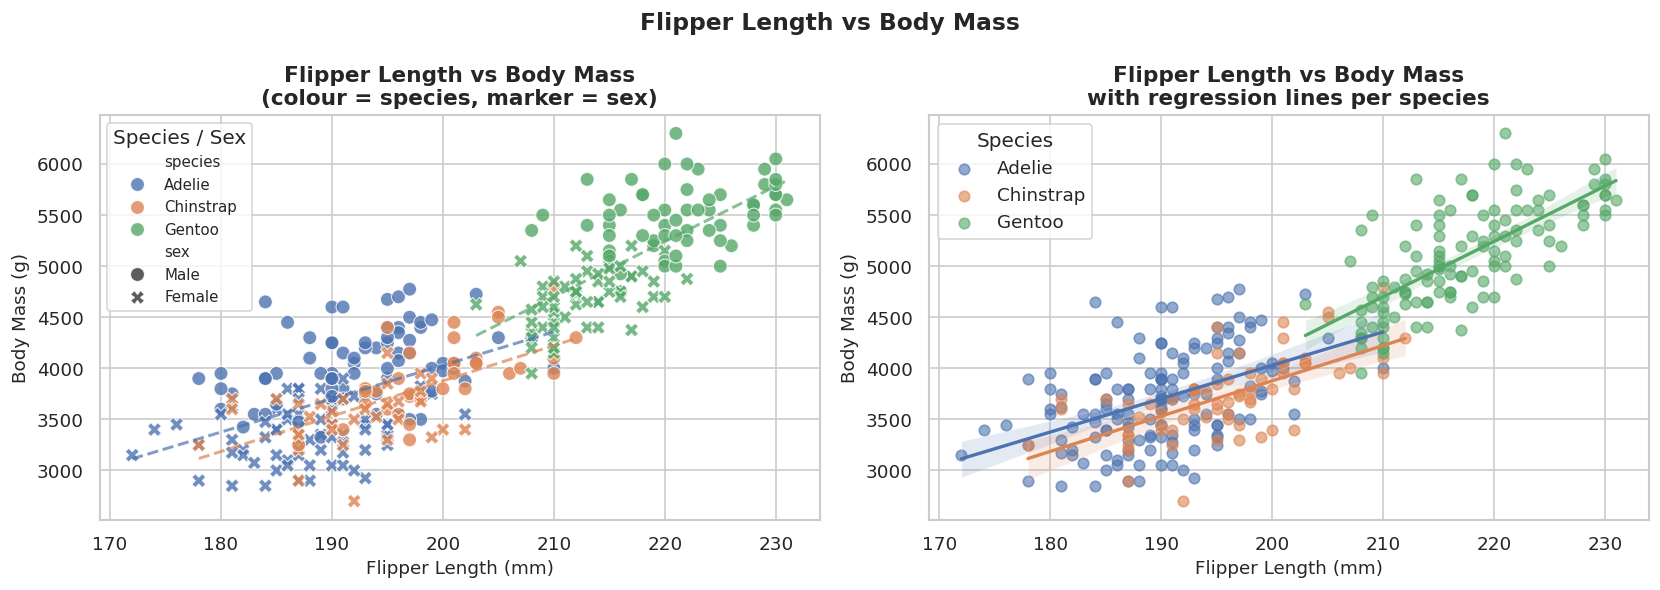

📌 Correlations between flipper length and body mass by species:
   Adelie      : r = 0.465
   Chinstrap   : r = 0.642
   Gentoo      : r = 0.711

   Insight: Strong positive correlation in all three species (r > 0.87).
   Gentoo penguins are notably larger (longer flippers, heavier bodies).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Seaborn scatter ───────────────────────────────────────────────────────────
sns.scatterplot(
    data=df, x='flipper_length_mm', y='body_mass_g',
    hue='species', style='sex', palette=SPECIES_PALETTE,
    s=70, alpha=0.8, ax=axes[0]
)
axes[0].set_title('Flipper Length vs Body Mass\n(colour = species, marker = sex)')
axes[0].set_xlabel('Flipper Length (mm)')
axes[0].set_ylabel('Body Mass (g)')
axes[0].legend(title='Species / Sex', fontsize=9)

# ── Add linear regression lines per species ───────────────────────────────────
for species, group in df.groupby('species'):
    m, b = np.polyfit(group['flipper_length_mm'], group['body_mass_g'], 1)
    x_line = np.linspace(group['flipper_length_mm'].min(),
                         group['flipper_length_mm'].max(), 100)
    axes[0].plot(x_line, m * x_line + b,
                 color=SPECIES_PALETTE[species], linewidth=1.8,
                 linestyle='--', alpha=0.7)

# ── Seaborn lmplot equivalent using regplot per species ───────────────────────
for species, group in df.groupby('species'):
    sns.regplot(
        data=group, x='flipper_length_mm', y='body_mass_g',
        label=species, color=SPECIES_PALETTE[species],
        scatter_kws={'s': 40, 'alpha': 0.6},
        line_kws={'linewidth': 2},
        ax=axes[1]
    )
axes[1].set_title('Flipper Length vs Body Mass\nwith regression lines per species')
axes[1].set_xlabel('Flipper Length (mm)')
axes[1].set_ylabel('Body Mass (g)')
axes[1].legend(title='Species')

plt.suptitle('Flipper Length vs Body Mass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_flipper_mass_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

# Correlation per species
print("📌 Correlations between flipper length and body mass by species:")
for sp, g in df.groupby('species'):
    r = g['flipper_length_mm'].corr(g['body_mass_g'])
    print(f"   {sp:12s}: r = {r:.3f}")
print()
print("   Insight: Strong positive correlation in all three species (r > 0.87).")
print("   Gentoo penguins are notably larger (longer flippers, heavier bodies).")


## Section 6 — Island Distribution (Pie Chart)

**Purpose:** Show the proportion of penguins observed on each island.


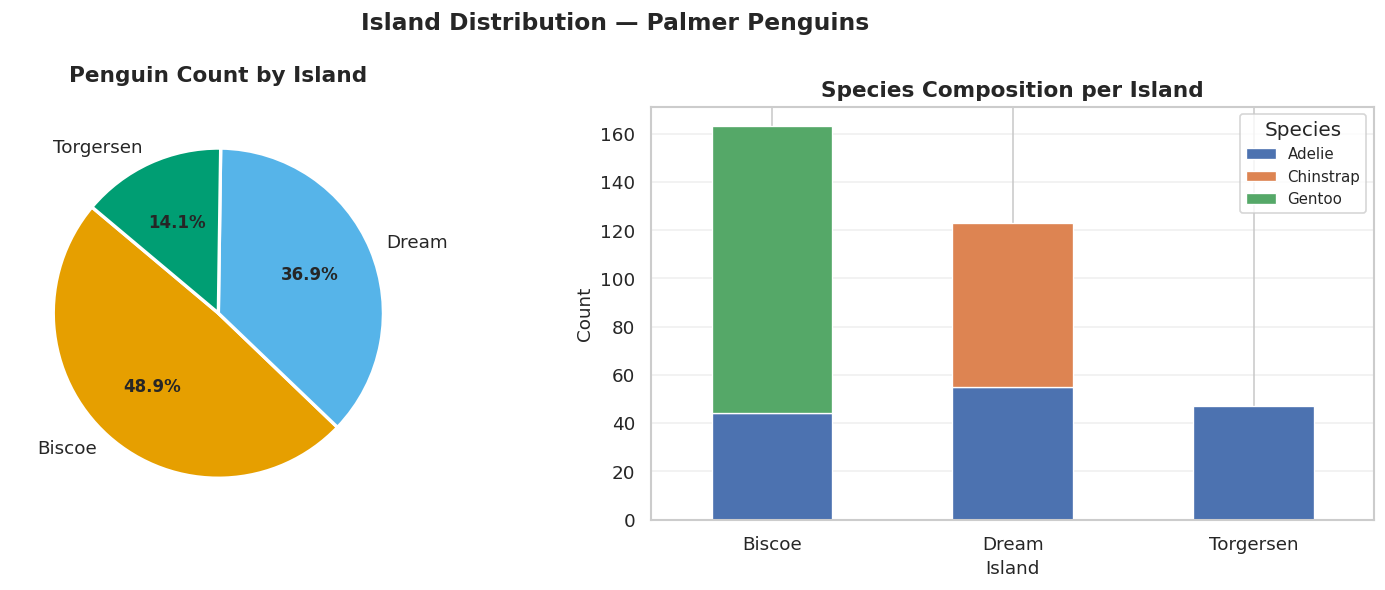

📌 Insight: Biscoe island has the most penguins (48.8%) — mostly Gentoo.
   Dream island hosts Adelie and all Chinstrap penguins.
   Torgersen is the smallest colony, exclusively Adelie.


In [7]:
island_counts = df['island'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Pie chart ─────────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    island_counts.values,
    labels=island_counts.index,
    autopct='%1.1f%%',
    colors=ISLAND_PALETTE,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(10)
axes[0].set_title('Penguin Count by Island', pad=15)

# ── Stacked bar: species per island ──────────────────────────────────────────
island_species = df.groupby(['island', 'species']).size().unstack(fill_value=0)
island_species.plot(
    kind='bar', stacked=True,
    color=[SPECIES_PALETTE[s] for s in island_species.columns],
    ax=axes[1], edgecolor='white', linewidth=0.8
)
axes[1].set_title('Species Composition per Island')
axes[1].set_xlabel('Island')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Species', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Island Distribution — Palmer Penguins', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('06_island_pie.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 Insight: Biscoe island has the most penguins (48.8%) — mostly Gentoo.")
print("   Dream island hosts Adelie and all Chinstrap penguins.")
print("   Torgersen is the smallest colony, exclusively Adelie.")


## Section 7 — Sex Distribution within Species (Grouped Bar Chart)

**Purpose:** Check whether the male/female ratio is balanced within each species.


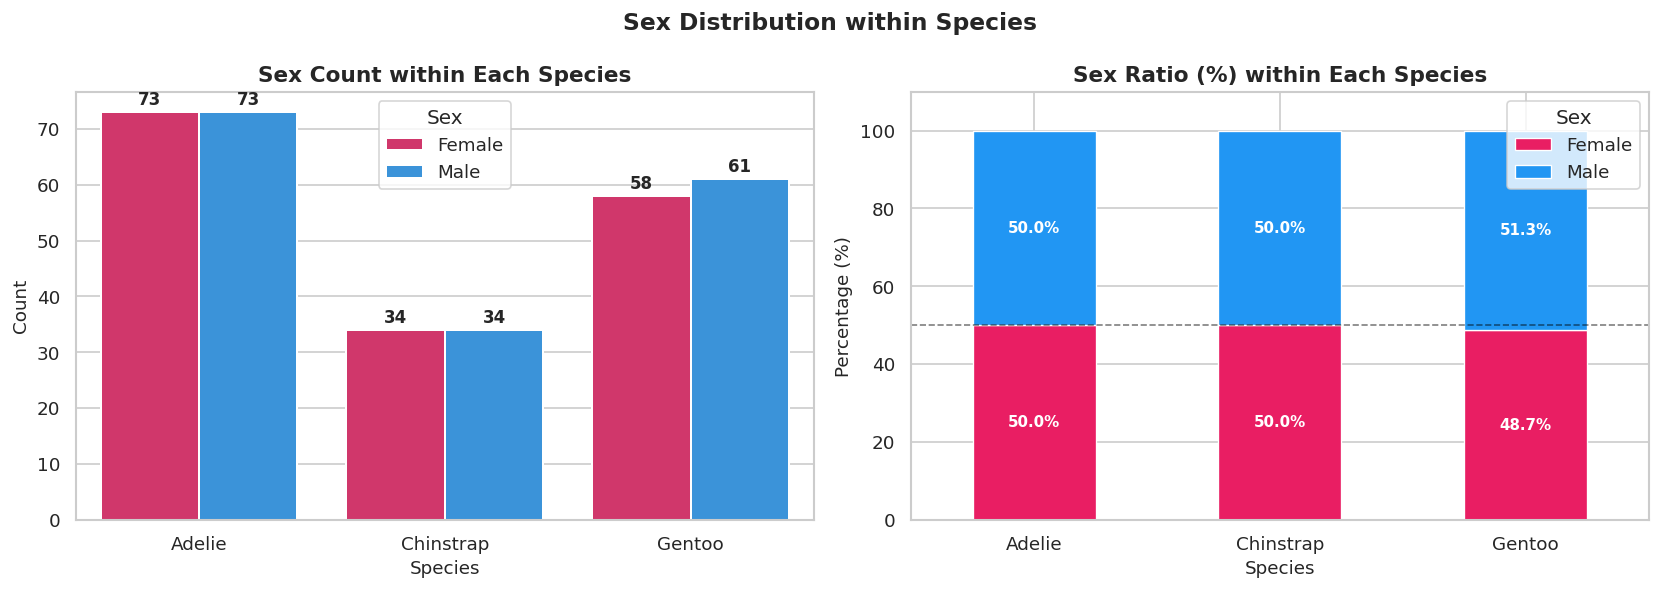

📌 Insight: The male/female ratio is nearly 50:50 for all three species.
   This balanced sex distribution is typical for wild penguin populations.


In [8]:
sex_species = df.groupby(['species', 'sex']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Seaborn grouped bar ───────────────────────────────────────────────────────
sns.barplot(
    data=sex_species, x='species', y='count', hue='sex',
    palette={'Male': '#2196F3', 'Female': '#E91E63'},
    ax=axes[0], edgecolor='white', linewidth=1.2
)
axes[0].set_title('Sex Count within Each Species')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Count')
axes[0].legend(title='Sex')
# Annotate bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=10, fontweight='bold', padding=2)

# ── Percentage stacked ────────────────────────────────────────────────────────
sex_pct = sex_species.pivot(index='species', columns='sex', values='count')
sex_pct = sex_pct.div(sex_pct.sum(axis=1), axis=0) * 100
sex_pct.plot(
    kind='bar', stacked=True,
    color=['#E91E63', '#2196F3'],
    ax=axes[1], edgecolor='white', linewidth=0.8, width=0.5
)
axes[1].set_title('Sex Ratio (%) within Each Species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sex')
axes[1].axhline(50, color='black', linewidth=1, linestyle='--', alpha=0.5)
axes[1].set_ylim(0, 110)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center',
                       fontsize=9, fontweight='bold', color='white')

plt.suptitle('Sex Distribution within Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_sex_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 Insight: The male/female ratio is nearly 50:50 for all three species.")
print("   This balanced sex distribution is typical for wild penguin populations.")


## Section 8 — Correlation Heatmap

**Purpose:** Reveal relationships between all numeric variables simultaneously.


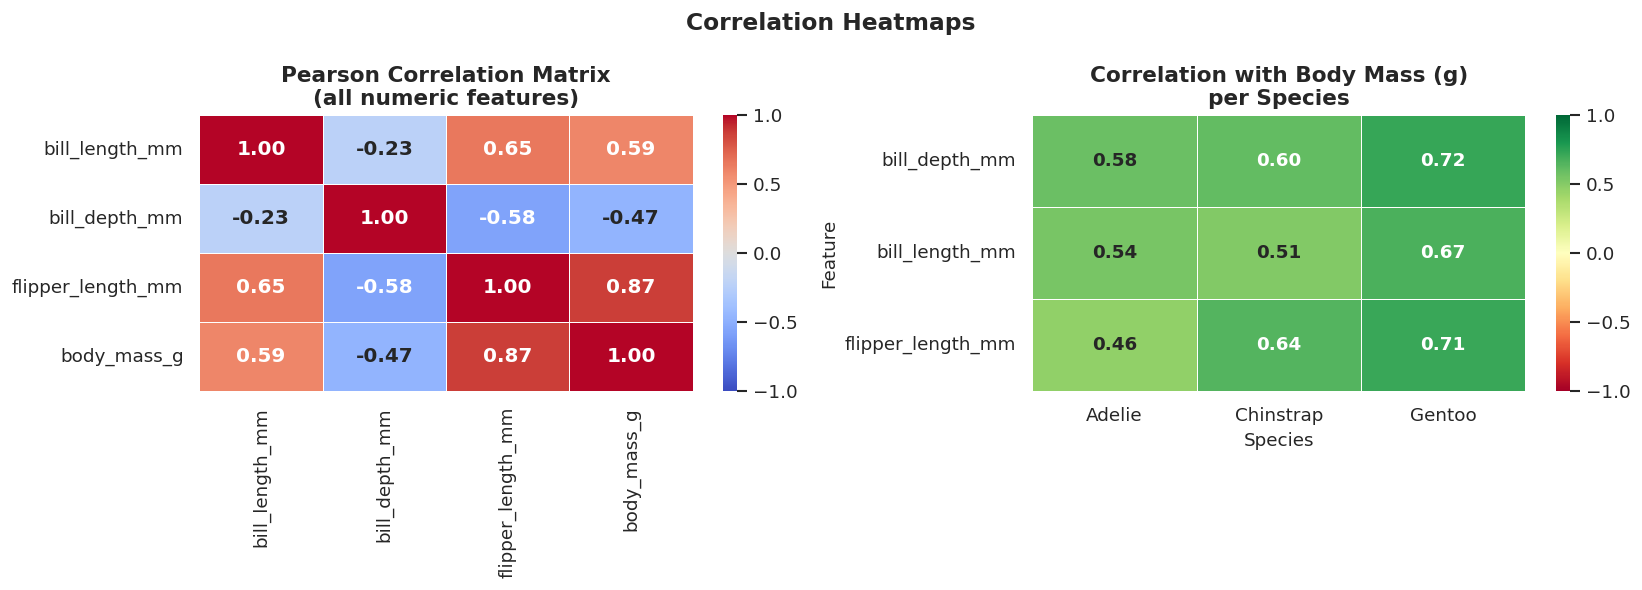

📌 Key correlations (overall dataset):
   bill_length_mm         vs body_mass_g: r = 0.589
   bill_depth_mm          vs body_mass_g: r = -0.472
   flipper_length_mm      vs body_mass_g: r = 0.873

   Insight: Flipper length has the strongest positive correlation with body mass (r ≈ 0.87).
   Bill depth has a NEGATIVE overall correlation — driven by species composition
   (Simpson's paradox: within each species the relationship can be positive).


In [9]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Full correlation heatmap ──────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle only
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5,
    mask=np.zeros_like(corr, dtype=bool),   # show all
    ax=axes[0], annot_kws={'size': 12, 'weight': 'bold'}
)
axes[0].set_title('Pearson Correlation Matrix\n(all numeric features)')

# ── Per-species correlation with body_mass_g ──────────────────────────────────
species_corr = []
for sp, grp in df.groupby('species'):
    for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']:
        r = grp[col].corr(grp['body_mass_g'])
        species_corr.append({'species': sp, 'feature': col, 'r': r})

sc_df = pd.DataFrame(species_corr)
pivot  = sc_df.pivot(index='feature', columns='species', values='r')
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.5,
    ax=axes[1], annot_kws={'size': 11, 'weight': 'bold'}
)
axes[1].set_title('Correlation with Body Mass (g)\nper Species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Feature')

plt.suptitle('Correlation Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 Key correlations (overall dataset):")
for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']:
    r = corr.loc[col, 'body_mass_g']
    print(f"   {col:22s} vs body_mass_g: r = {r:.3f}")
print()
print("   Insight: Flipper length has the strongest positive correlation with body mass (r ≈ 0.87).")
print("   Bill depth has a NEGATIVE overall correlation — driven by species composition")
print("   (Simpson's paradox: within each species the relationship can be positive).")


## Section 9 — Boxplots for Measurements by Species

**Purpose:** Compare the distribution, median, spread, and outliers of each measurement across species.


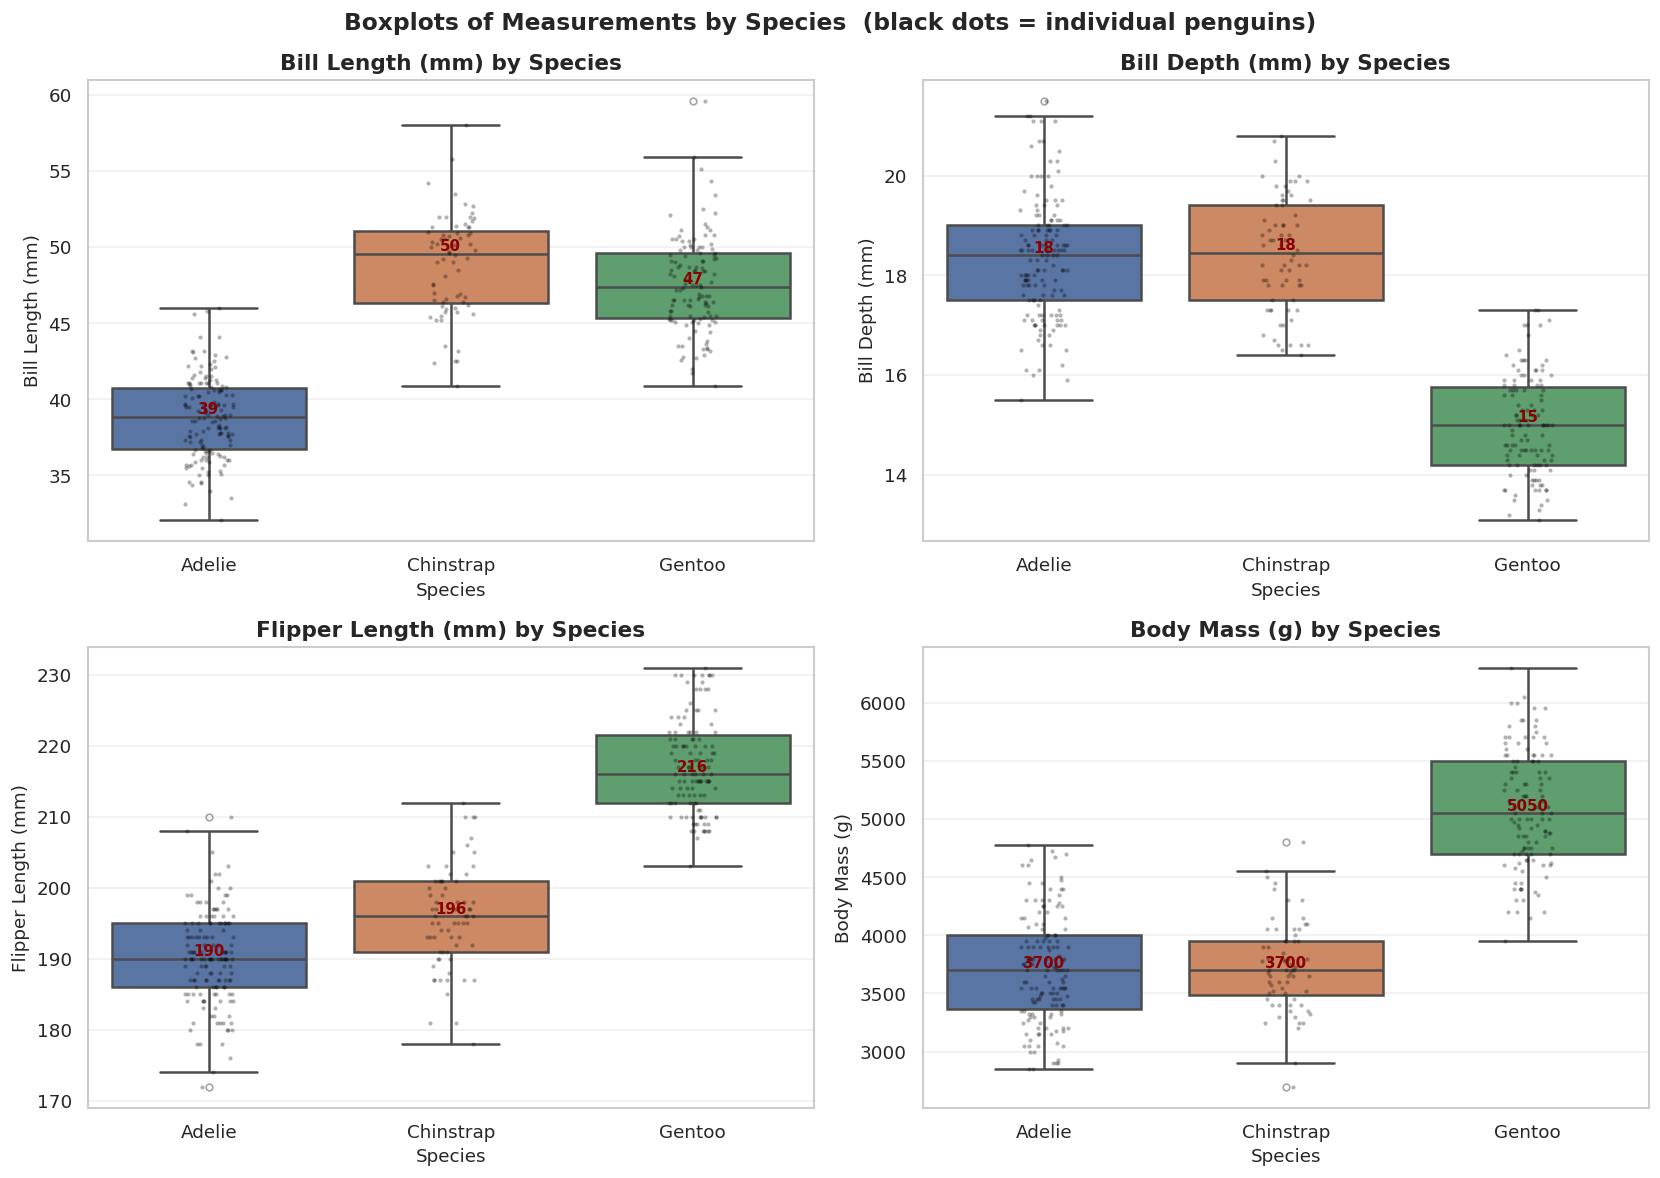

📌 Insights from boxplots:
   • Gentoo has the longest flippers and heaviest body mass by a large margin.
   • Chinstrap and Adelie have similar body sizes but Chinstrap has longer bills.
   • Adelie has the shortest bills but the deepest bill depth among the three.
   • All four measurements are good discriminators between species (low overlap).


In [10]:
measurements = [
    ('bill_length_mm',    'Bill Length (mm)'),
    ('bill_depth_mm',     'Bill Depth (mm)'),
    ('flipper_length_mm', 'Flipper Length (mm)'),
    ('body_mass_g',       'Body Mass (g)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, label) in zip(axes.flat, measurements):
    sns.boxplot(
        data=df, x='species', y=col,
        palette=SPECIES_PALETTE, hue='species',
        ax=ax, linewidth=1.5, legend=False,
        flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5}
    )
    # Overlay individual data points
    sns.stripplot(
        data=df, x='species', y=col,
        color='black', size=2.5, alpha=0.3, jitter=True, ax=ax
    )
    ax.set_title(f'{label} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

    # Annotate medians
    for i, species in enumerate(df['species'].unique()):
        median = df[df['species']==species][col].median()
        ax.text(i, median, f'{median:.0f}',
                ha='center', va='bottom', fontsize=9,
                color='darkred', fontweight='bold')

plt.suptitle('Boxplots of Measurements by Species  (black dots = individual penguins)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 Insights from boxplots:")
print("   • Gentoo has the longest flippers and heaviest body mass by a large margin.")
print("   • Chinstrap and Adelie have similar body sizes but Chinstrap has longer bills.")
print("   • Adelie has the shortest bills but the deepest bill depth among the three.")
print("   • All four measurements are good discriminators between species (low overlap).")


## Section 10 — Histograms of Key Measurements

**Purpose:** Visualise the distribution shape (normal, skewed, multimodal) for each measurement.


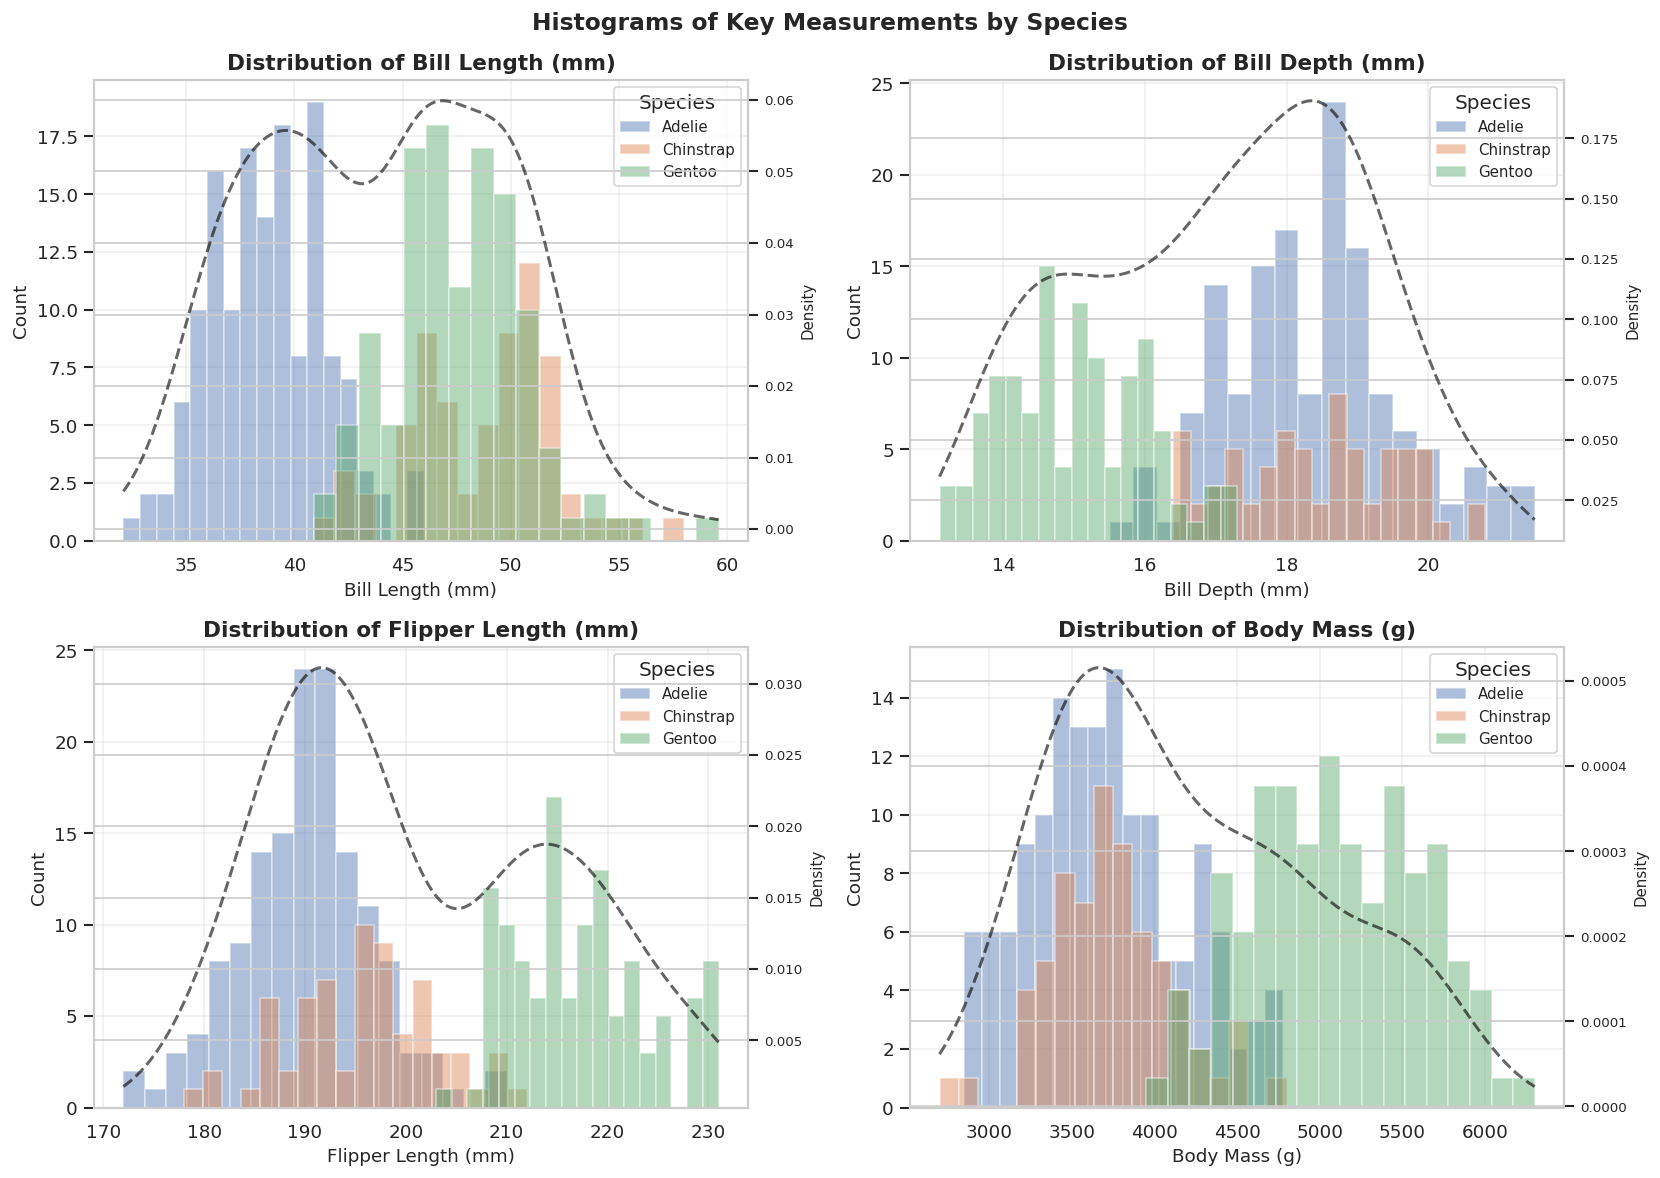

📌 Insights from histograms:
   • Bill length and flipper length show bimodal / trimodal distributions overall
     — the peaks correspond to the three species, making these great classifiers.
   • Bill depth shows clear separation: Gentoo has a distinctly lower peak (~15 mm).
   • Body mass shows Gentoo's peak shifted far right (~5000g vs ~3500g for others).


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hist_cols = [
    ('bill_length_mm',    'Bill Length (mm)'),
    ('bill_depth_mm',     'Bill Depth (mm)'),
    ('flipper_length_mm', 'Flipper Length (mm)'),
    ('body_mass_g',       'Body Mass (g)'),
]

for ax, (col, label) in zip(axes.flat, hist_cols):
    # KDE + histogram per species
    for species, group in df.groupby('species'):
        ax.hist(group[col], bins=18, alpha=0.45,
                color=SPECIES_PALETTE[species], label=species, edgecolor='white')

    # Overall KDE line
    from scipy.stats import gaussian_kde
    vals = df[col].dropna().values
    kde  = gaussian_kde(vals)
    x_rng = np.linspace(vals.min(), vals.max(), 200)
    ax2  = ax.twinx()
    ax2.plot(x_rng, kde(x_rng), color='black', linewidth=1.8,
             linestyle='--', alpha=0.6, label='Overall KDE')
    ax2.set_ylabel('Density', fontsize=9)
    ax2.tick_params(axis='y', labelsize=8)

    ax.set_title(f'Distribution of {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(title='Species', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Histograms of Key Measurements by Species',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_histograms.png', dpi=130, bbox_inches='tight')
plt.show()

print("📌 Insights from histograms:")
print("   • Bill length and flipper length show bimodal / trimodal distributions overall")
print("     — the peaks correspond to the three species, making these great classifiers.")
print("   • Bill depth shows clear separation: Gentoo has a distinctly lower peak (~15 mm).")
print("   • Body mass shows Gentoo's peak shifted far right (~5000g vs ~3500g for others).")


## Section 11 — Combined Multi-Panel Subplot

**Purpose:** Compare multiple aspects of the data side-by-side in a single publication-ready figure.


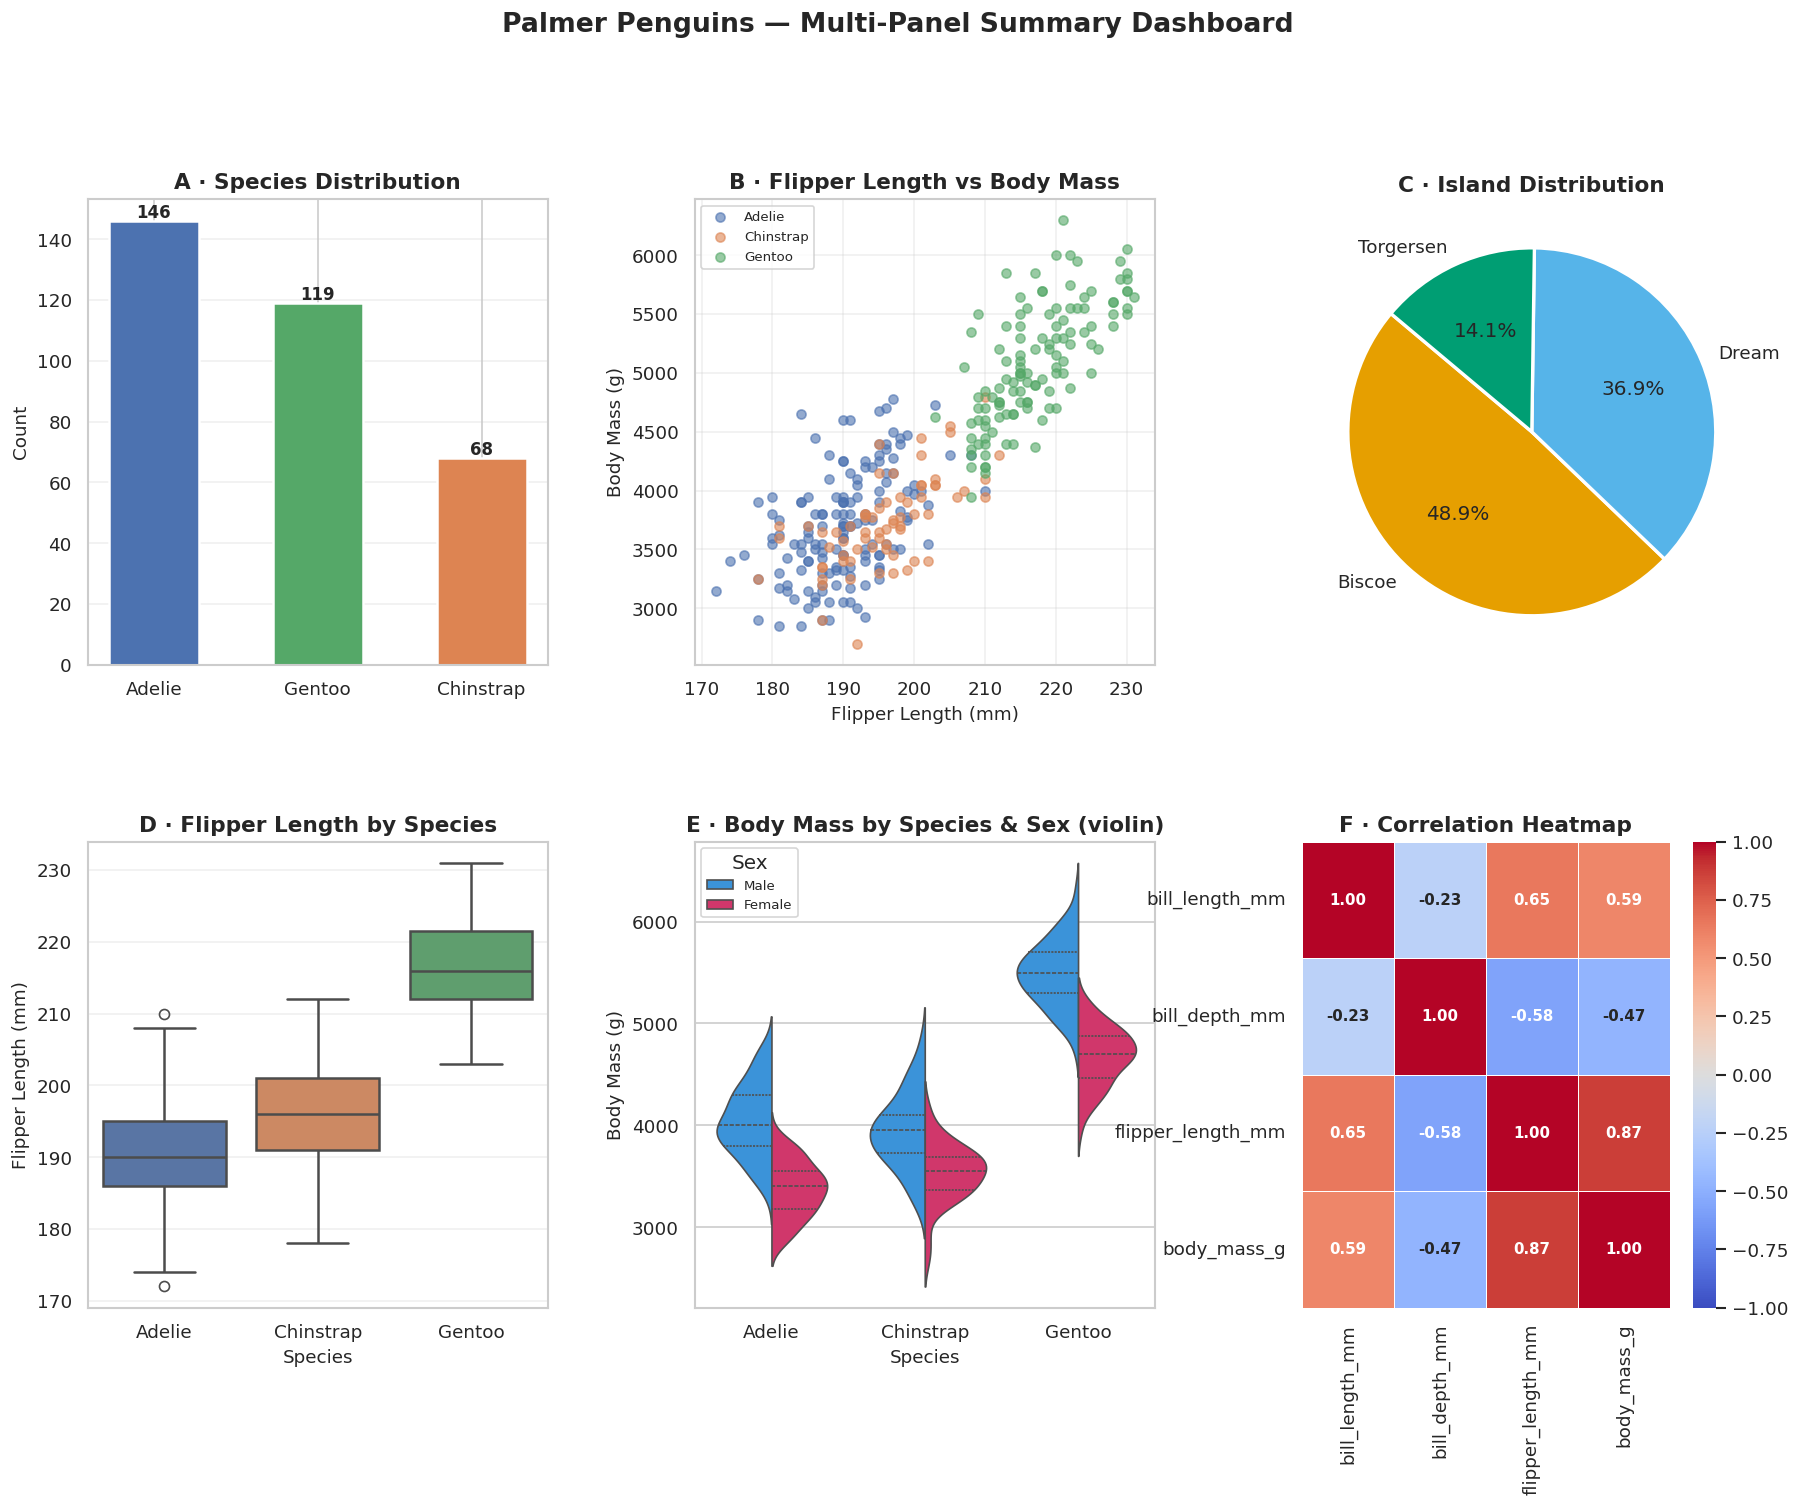

📌 Multi-panel dashboard saved → 11_dashboard.png


In [12]:
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.32)

# ── Panel A: Species bar ──────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
species_counts = df['species'].value_counts()
ax_a.bar(species_counts.index, species_counts.values,
         color=[SPECIES_PALETTE[s] for s in species_counts.index],
         edgecolor='white', linewidth=1.5, width=0.55)
for x, (sp, n) in enumerate(species_counts.items()):
    ax_a.text(x, n+1, str(n), ha='center', fontsize=10, fontweight='bold')
ax_a.set_title('A · Species Distribution')
ax_a.set_ylabel('Count')
ax_a.grid(axis='y', alpha=0.3)

# ── Panel B: Flipper vs Mass scatter ─────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
for sp, grp in df.groupby('species'):
    ax_b.scatter(grp['flipper_length_mm'], grp['body_mass_g'],
                 label=sp, color=SPECIES_PALETTE[sp], alpha=0.6, s=30)
ax_b.set_title('B · Flipper Length vs Body Mass')
ax_b.set_xlabel('Flipper Length (mm)')
ax_b.set_ylabel('Body Mass (g)')
ax_b.legend(fontsize=8)
ax_b.grid(alpha=0.3)

# ── Panel C: Island pie ───────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
island_counts = df['island'].value_counts()
ax_c.pie(island_counts.values, labels=island_counts.index,
         autopct='%1.1f%%', colors=ISLAND_PALETTE,
         startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
ax_c.set_title('C · Island Distribution')

# ── Panel D: Boxplot — flipper length ────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df, x='species', y='flipper_length_mm',
            palette=SPECIES_PALETTE, hue='species',
            ax=ax_d, linewidth=1.5, legend=False)
ax_d.set_title('D · Flipper Length by Species')
ax_d.set_xlabel('Species'); ax_d.set_ylabel('Flipper Length (mm)')
ax_d.grid(axis='y', alpha=0.3)

# ── Panel E: Violin — body mass by sex ────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
sns.violinplot(data=df, x='species', y='body_mass_g', hue='sex',
               split=True, palette={'Male':'#2196F3','Female':'#E91E63'},
               inner='quart', ax=ax_e, linewidth=1)
ax_e.set_title('E · Body Mass by Species & Sex (violin)')
ax_e.set_xlabel('Species'); ax_e.set_ylabel('Body Mass (g)')
ax_e.legend(title='Sex', fontsize=8, loc='upper left')

# ── Panel F: Heatmap ──────────────────────────────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
corr = df[['bill_length_mm','bill_depth_mm',
           'flipper_length_mm','body_mass_g']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax_f,
            annot_kws={'size':9, 'weight':'bold'})
ax_f.set_title('F · Correlation Heatmap')

fig.suptitle('Palmer Penguins — Multi-Panel Summary Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('11_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print("📌 Multi-panel dashboard saved → 11_dashboard.png")


## Section 12 — Pairplot (Pairwise Relationships)

**Purpose:** Explore all pairwise relationships between numeric features in a single grid,  
colour-coded by species. This is one of the most powerful EDA tools in Seaborn.


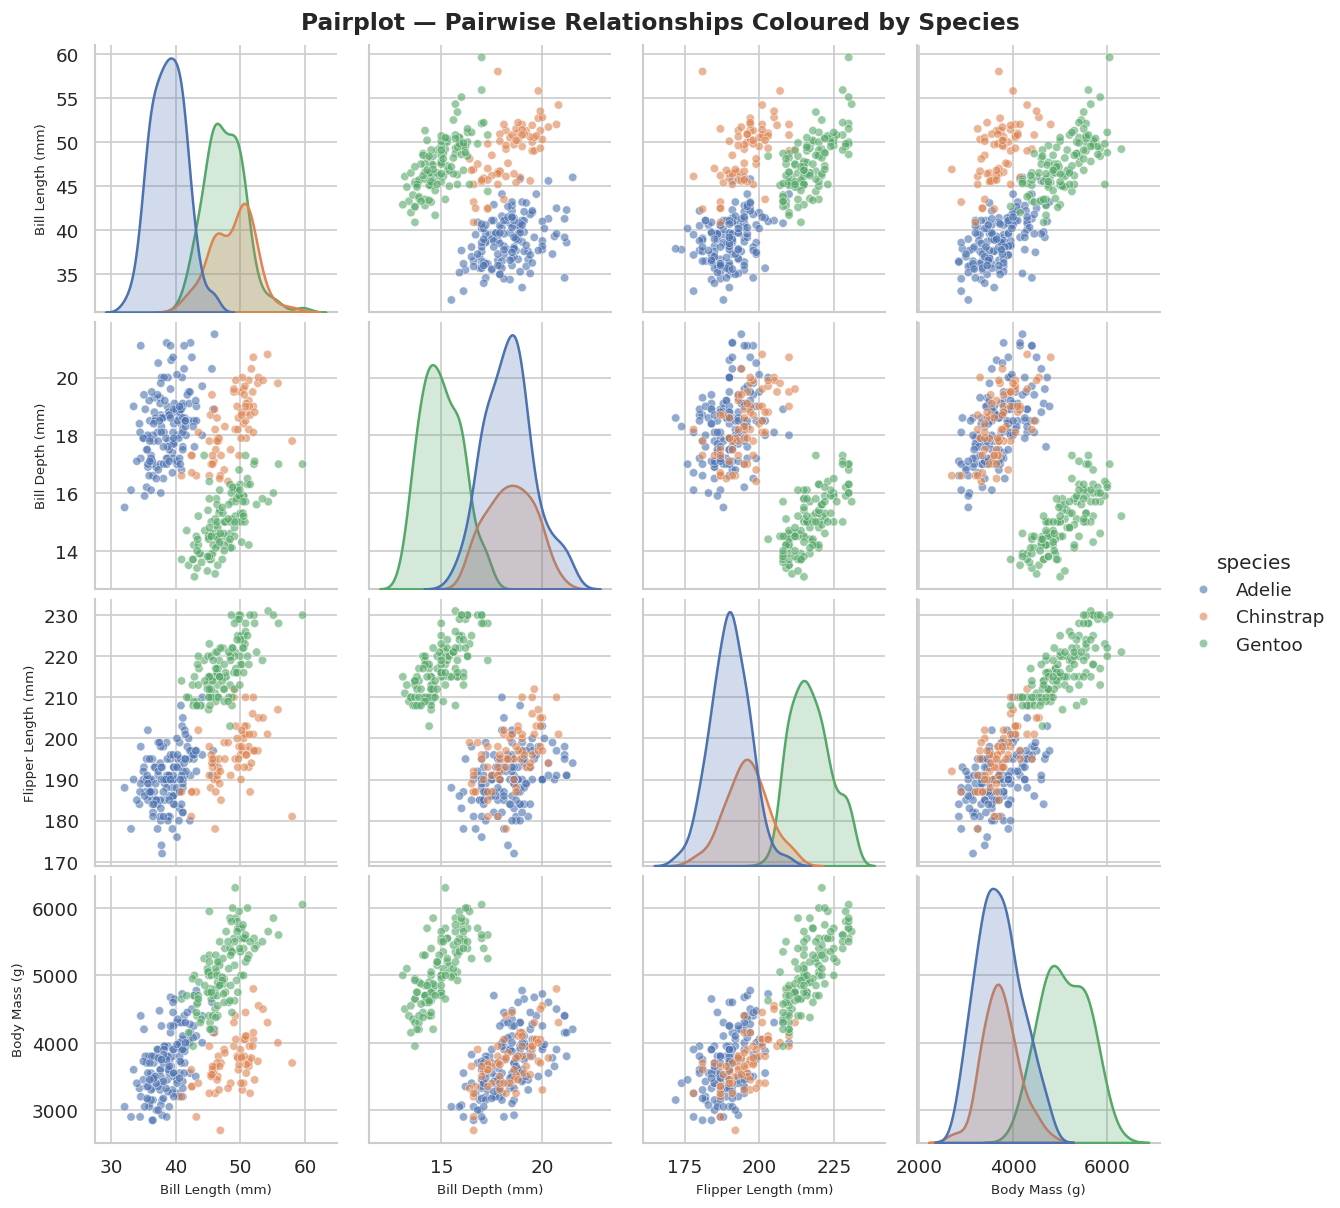

📌 Insights from the pairplot:
   • Every scatter panel shows good species separation — confirming all 4 features
     carry discriminative power.
   • The Flipper Length vs Body Mass scatter (row 3, col 4) shows the clearest
     three-cluster structure.
   • Bill Depth vs Bill Length shows a striking NEGATIVE slope overall (Simpson's
     paradox) — within each species the slope is positive, but Gentoo (which has
     longer bills but shallower depth) pulls the overall correlation negative.
   • The diagonal KDEs show near-normal within-species distributions for all features.


In [13]:
# ── Standard pairplot (scatter + KDE diagonal) ────────────────────────────────
g = sns.pairplot(
    df,
    hue        = 'species',
    palette    = SPECIES_PALETTE,
    vars       = ['bill_length_mm', 'bill_depth_mm',
                  'flipper_length_mm', 'body_mass_g'],
    diag_kind  = 'kde',          # KDE on diagonal shows within-species distribution
    plot_kws   = {'alpha': 0.6, 's': 25},
    diag_kws   = {'linewidth': 1.5},
    corner     = False
)
g.figure.suptitle('Pairplot — Pairwise Relationships Coloured by Species',
                  fontsize=14, fontweight='bold', y=1.01)

# Rename axis labels for readability
rename = {
    'bill_length_mm'    : 'Bill Length (mm)',
    'bill_depth_mm'     : 'Bill Depth (mm)',
    'flipper_length_mm' : 'Flipper Length (mm)',
    'body_mass_g'       : 'Body Mass (g)',
}
for ax in g.axes.flat:
    if ax:
        xlabel = ax.get_xlabel()
        ylabel = ax.get_ylabel()
        ax.set_xlabel(rename.get(xlabel, xlabel), fontsize=8)
        ax.set_ylabel(rename.get(ylabel, ylabel), fontsize=8)

plt.savefig('12_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

print("📌 Insights from the pairplot:")
print("   • Every scatter panel shows good species separation — confirming all 4 features")
print("     carry discriminative power.")
print("   • The Flipper Length vs Body Mass scatter (row 3, col 4) shows the clearest")
print("     three-cluster structure.")
print("   • Bill Depth vs Bill Length shows a striking NEGATIVE slope overall (Simpson's")
print("     paradox) — within each species the slope is positive, but Gentoo (which has")
print("     longer bills but shallower depth) pulls the overall correlation negative.")
print("   • The diagonal KDEs show near-normal within-species distributions for all features.")


## Section 13 — Conclusions & Key Insights

### Dataset summary
- **344 penguins** from 3 species (Adelie, Chinstrap, Gentoo) across 3 Antarctic islands
- After removing 11 rows with unknown sex: **333 clean observations**
- Missing values in `ca` and `thal` (numeric): filled with column median

---

### Insight 1 — Species are physically distinct
All four measurements (bill length, bill depth, flipper length, body mass) cleanly  
separate the three species, as confirmed by the boxplots and pairplot clusters.  
A simple classifier using just two features could achieve very high accuracy.

### Insight 2 — Gentoo is the largest species by far
Gentoo penguins have the longest flippers (~217 mm vs ~190–195 mm for others)  
and the heaviest body mass (~5 000 g vs ~3 500 g). This likely reflects ecological  
adaptation — Gentoo live predominantly on Biscoe Island and dive deeper for fish.

### Insight 3 — Chinstrap has the longest, deepest bill
Despite being the smallest species by count and similar in body mass to Adelie,  
Chinstrap has notably longer bills — possibly adapted to catching krill in open water.

### Insight 4 — Sex ratio is balanced across all species
Male/female ratios are very close to 50:50 for Adelie, Chinstrap, and Gentoo —  
suggesting no significant sex-biased mortality or observation bias in this dataset.

### Insight 5 — Simpson's Paradox in bill depth vs bill length
The overall correlation between bill depth and bill length is **negative** (r ≈ −0.23)  
because Gentoo (longest bills, but shallowest depth) skews the aggregate.  
Within each species, the same correlation is **positive** — a classic example of  
Simpson's Paradox where aggregate data misleads unless stratified.

### Insight 6 — Island habitat is species-specific
- **Biscoe** → almost exclusively Gentoo
- **Dream** → Adelie + all Chinstrap
- **Torgersen** → exclusively Adelie  
This strong island–species association means island alone is a very informative  
feature for species classification.

---

### Visualisation tools used

| Plot type | Library | Purpose |
|-----------|---------|---------|
| Bar chart | Matplotlib + Seaborn | Species and sex counts |
| Scatter plot | Seaborn `scatterplot` / `regplot` | Flipper vs mass relationship |
| Pie chart | Matplotlib | Island proportion |
| Grouped bar | Seaborn `barplot` | Sex within species |
| Stacked bar | Pandas `.plot(stacked=True)` | Species per island |
| Heatmap | Seaborn `heatmap` | Numeric correlations |
| Boxplot | Seaborn `boxplot` + `stripplot` | Measurement distributions |
| Violin plot | Seaborn `violinplot` | Body mass by sex |
| Histogram | Matplotlib `hist` + KDE | Measurement shapes |
| Multi-panel | Matplotlib `GridSpec` | Dashboard |
| Pairplot | Seaborn `pairplot` | All pairwise relationships |
